In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Charger les mesures et la vérité terrain (ground truth)
mesures = pd.read_csv("../data/mesures_synthetiques.csv", parse_dates=["timestamp"])
verite = pd.read_csv("../data/anomalies_verite_terrain.csv", parse_dates=["timestamp"])

In [4]:
# On se concentre sur un seul site pour l'instant : en prend le site 1
site_1 = mesures[mesures["site_id"] == 1].set_index("timestamp")
anomalies_site_1 = verite[verite["site_id"] == 1]

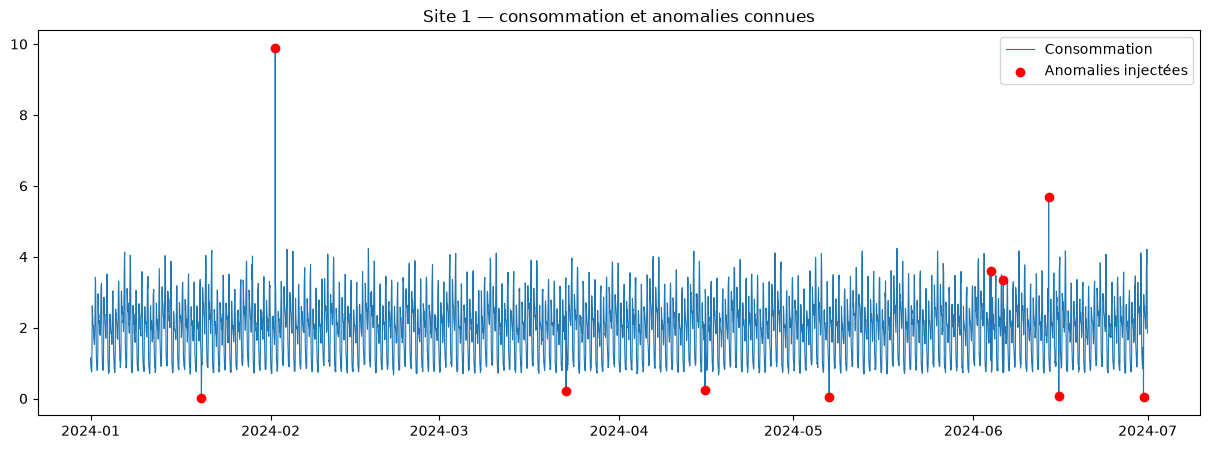

In [5]:
# Tracer la courbe complète, avec les anomalies marquées en rouge
plt.figure(figsize=(15, 5))
plt.plot(site_1.index, site_1["valeur_kwh"], label="Consommation", linewidth=0.8)
plt.scatter(
    anomalies_site_1["timestamp"],
    anomalies_site_1["valeur_injectee"],
    color="red", label="Anomalies injectées", zorder=5
)
plt.legend()
plt.title("Site 1 — consommation et anomalies connues")
plt.show()

In [6]:
FENETRE = 24 * 7  # 7 jours en heures, pour capter un cycle hebdomadaire complet
SEUIL_ECART_TYPE = 3

site_1["moyenne_mobile"] = site_1["valeur_kwh"].rolling(FENETRE, min_periods=24).mean()
site_1["ecart_type_mobile"] = site_1["valeur_kwh"].rolling(FENETRE, min_periods=24).std()

site_1["borne_haute"] = site_1["moyenne_mobile"] + SEUIL_ECART_TYPE * site_1["ecart_type_mobile"]
site_1["borne_basse"] = site_1["moyenne_mobile"] - SEUIL_ECART_TYPE * site_1["ecart_type_mobile"]

site_1["anomalie_detectee"] = (
    (site_1["valeur_kwh"] > site_1["borne_haute"]) |
    (site_1["valeur_kwh"] < site_1["borne_basse"])
)

detections = site_1[site_1["anomalie_detectee"]]
print(f"{len(detections)} anomalies détectées sur le site 1")
print(detections[["valeur_kwh"]])

2 anomalies détectées sur le site 1
                     valeur_kwh
timestamp                      
2024-02-01 19:00:00       9.891
2024-06-13 23:00:00       5.686


In [7]:
verite_1 = verite[verite["site_id"] == 1].copy()
diagnostic = site_1.loc[verite_1["timestamp"]][["valeur_kwh", "moyenne_mobile", "ecart_type_mobile", "borne_haute", "borne_basse"]]
print(diagnostic)

                     valeur_kwh  moyenne_mobile  ecart_type_mobile  \
timestamp                                                            
2024-01-20 02:00:00       0.018        1.995565           0.818424   
2024-02-01 19:00:00       9.891        2.035804           1.007528   
2024-03-22 21:00:00       0.215        1.980327           0.815574   
2024-04-15 19:00:00       0.235        1.984875           0.821009   
2024-05-07 04:00:00       0.041        1.988226           0.816692   
2024-06-04 02:00:00       3.590        2.029952           0.834567   
2024-06-06 04:00:00       3.356        2.038446           0.834898   
2024-06-13 23:00:00       5.686        2.013286           0.860394   
2024-06-15 17:00:00       0.069        2.009440           0.876928   
2024-06-30 07:00:00       0.055        1.967363           0.823857   

                     borne_haute  borne_basse  
timestamp                                      
2024-01-20 02:00:00     4.450836    -0.459705  
2024-02-01 19:0

In [10]:
# Recalcul des facteurs horaire/hebdo (comme à l'étape 4 et dans generate_synthetic_data.py)
df_horaire = pd.read_csv("../data/conso_horaire_propre.csv", index_col="timestamp", parse_dates=True)
conso_ref = df_horaire[["Global_active_power"]].rename(columns={"Global_active_power": "conso_kw"})
conso_ref["heure"] = conso_ref.index.hour
conso_ref["jour_semaine"] = conso_ref.index.dayofweek

profil_horaire = conso_ref.groupby("heure")["conso_kw"].mean()
profil_hebdo = conso_ref.groupby("jour_semaine")["conso_kw"].mean()
moyenne_globale = conso_ref["conso_kw"].mean()

facteur_horaire = profil_horaire / moyenne_globale
facteur_hebdo = profil_hebdo / moyenne_globale


# Réutiliser le profil horaire déjà calculé (facteur_horaire, facteur_hebdo, à l'étape 5)
# Reconstruire la valeur "attendue" pour ce site
echelle_site_1 = 2.0  # échelle du site 1, définie à l'étape 5

site_1["heure"] = site_1.index.hour
site_1["jour_semaine"] = site_1.index.dayofweek
site_1["valeur_attendue"] = (
    facteur_horaire[site_1["heure"]].values
    * facteur_hebdo[site_1["jour_semaine"]].values
    * echelle_site_1
)

# Le résidu : écart entre observé et attendu (peut être négatif, c'est voulu)
site_1["residu"] = site_1["valeur_kwh"] - site_1["valeur_attendue"]

# Fenêtre glissante appliquée au résidu, pas à la valeur brute
FENETRE = 24 * 7
site_1["residu_moyenne"] = site_1["residu"].rolling(FENETRE, min_periods=24).mean()
site_1["residu_ecart_type"] = site_1["residu"].rolling(FENETRE, min_periods=24).std()

SEUIL = 3
site_1["borne_haute"] = site_1["residu_moyenne"] + SEUIL * site_1["residu_ecart_type"]
site_1["borne_basse"] = site_1["residu_moyenne"] - SEUIL * site_1["residu_ecart_type"]

site_1["anomalie_detectee"] = (
    (site_1["residu"] > site_1["borne_haute"]) |
    (site_1["residu"] < site_1["borne_basse"])
)

detections = site_1[site_1["anomalie_detectee"]]
print(f"{len(detections)} anomalies détectées sur le site 1")
print(detections[["valeur_kwh", "valeur_attendue", "residu"]])

43 anomalies détectées sur le site 1
                     valeur_kwh  valeur_attendue    residu
timestamp                                                 
2024-01-09 17:00:00       2.278         1.910058  0.367942
2024-01-10 20:00:00       3.100         3.449682 -0.349682
2024-01-11 22:00:00       1.950         2.327653 -0.377653
2024-01-12 20:00:00       3.666         3.313097  0.352903
2024-01-20 02:00:00       0.018         1.010566 -0.992566
2024-01-20 22:00:00       3.375         2.924506  0.450494
2024-01-27 22:00:00       2.530         2.924506 -0.394506
2024-01-28 20:00:00       3.346         3.856809 -0.510809
2024-02-01 19:00:00       9.891         2.849692  7.041308
2024-02-08 21:00:00       2.747         3.086320 -0.339320
2024-02-15 21:00:00       2.639         3.086320 -0.447320
2024-02-18 08:00:00       2.596         2.966441 -0.370441
2024-02-23 19:00:00       3.401         3.023777  0.377223
2024-02-28 21:00:00       3.779         3.409869  0.369131
2024-03-07 07:00:00

In [11]:
timestamps_detectes = set(detections.index)
timestamps_reels = set(verite_1["timestamp"])

vrais_positifs = timestamps_detectes & timestamps_reels
faux_positifs = timestamps_detectes - timestamps_reels
faux_negatifs = timestamps_reels - timestamps_detectes

precision = len(vrais_positifs) / len(timestamps_detectes)
recall = len(vrais_positifs) / len(timestamps_reels)

print(f"Vrais positifs : {len(vrais_positifs)}")
print(f"Faux positifs : {len(faux_positifs)}")
print(f"Faux négatifs : {len(faux_negatifs)}")
print(f"Précision : {precision:.2%}")
print(f"Recall : {recall:.2%}")

Vrais positifs : 10
Faux positifs : 33
Faux négatifs : 0
Précision : 23.26%
Recall : 100.00%


In [12]:
for seuil in [3, 4, 5]:
    site_1["borne_haute"] = site_1["residu_moyenne"] + seuil * site_1["residu_ecart_type"]
    site_1["borne_basse"] = site_1["residu_moyenne"] - seuil * site_1["residu_ecart_type"]
    site_1["anomalie_detectee"] = (
        (site_1["residu"] > site_1["borne_haute"]) |
        (site_1["residu"] < site_1["borne_basse"])
    )
    detections = site_1[site_1["anomalie_detectee"]]

    timestamps_detectes = set(detections.index)
    vrais_positifs = timestamps_detectes & timestamps_reels
    faux_positifs = timestamps_detectes - timestamps_reels
    faux_negatifs = timestamps_reels - timestamps_detectes

    precision = len(vrais_positifs) / len(timestamps_detectes) if timestamps_detectes else 0
    recall = len(vrais_positifs) / len(timestamps_reels)

    print(f"Seuil={seuil} | VP={len(vrais_positifs)} FP={len(faux_positifs)} FN={len(faux_negatifs)} | Précision={precision:.2%} Recall={recall:.2%}")

Seuil=3 | VP=10 FP=33 FN=0 | Précision=23.26% Recall=100.00%
Seuil=4 | VP=10 FP=3 FN=0 | Précision=76.92% Recall=100.00%
Seuil=5 | VP=10 FP=0 FN=0 | Précision=100.00% Recall=100.00%


In [13]:
sites_info = pd.read_csv("../data/sites.csv")

resultats_globaux = []

for _, site_row in sites_info.iterrows():
    site_id = site_row["id"]
    echelle = site_row["echelle"]

    site_data = mesures[mesures["site_id"] == site_id].set_index("timestamp").copy()
    site_data["heure"] = site_data.index.hour
    site_data["jour_semaine"] = site_data.index.dayofweek
    site_data["valeur_attendue"] = (
        facteur_horaire[site_data["heure"]].values
        * facteur_hebdo[site_data["jour_semaine"]].values
        * echelle
    )
    site_data["residu"] = site_data["valeur_kwh"] - site_data["valeur_attendue"]

    FENETRE = 24 * 7
    site_data["residu_moyenne"] = site_data["residu"].rolling(FENETRE, min_periods=24).mean()
    site_data["residu_ecart_type"] = site_data["residu"].rolling(FENETRE, min_periods=24).std()

    SEUIL = 5
    site_data["borne_haute"] = site_data["residu_moyenne"] + SEUIL * site_data["residu_ecart_type"]
    site_data["borne_basse"] = site_data["residu_moyenne"] - SEUIL * site_data["residu_ecart_type"]
    site_data["anomalie_detectee"] = (
        (site_data["residu"] > site_data["borne_haute"]) |
        (site_data["residu"] < site_data["borne_basse"])
    )

    detections = set(site_data[site_data["anomalie_detectee"]].index)
    reels = set(verite[verite["site_id"] == site_id]["timestamp"])

    vp = detections & reels
    fp = detections - reels
    fn = reels - detections

    precision = len(vp) / len(detections) if detections else 0
    recall = len(vp) / len(reels) if reels else 0

    resultats_globaux.append({"site_id": site_id, "VP": len(vp), "FP": len(fp), "FN": len(fn),
                                "precision": precision, "recall": recall})

df_resultats = pd.DataFrame(resultats_globaux)
print(df_resultats)

   site_id  VP  FP  FN  precision  recall
0        1  10   0   0   1.000000     1.0
1        2   9   0   1   1.000000     0.9
2        3  10   0   0   1.000000     1.0
3        4   8   0   2   1.000000     0.8
4        5   8   1   2   0.888889     0.8


In [14]:
for site_id in [4, 5]:
    site_data = mesures[mesures["site_id"] == site_id].set_index("timestamp").copy()
    echelle = sites_info.loc[sites_info["id"] == site_id, "echelle"].values[0]

    site_data["heure"] = site_data.index.hour
    site_data["jour_semaine"] = site_data.index.dayofweek
    site_data["valeur_attendue"] = (
        facteur_horaire[site_data["heure"]].values
        * facteur_hebdo[site_data["jour_semaine"]].values
        * echelle
    )
    site_data["residu"] = site_data["valeur_kwh"] - site_data["valeur_attendue"]
    site_data["residu_moyenne"] = site_data["residu"].rolling(24*7, min_periods=24).mean()
    site_data["residu_ecart_type"] = site_data["residu"].rolling(24*7, min_periods=24).std()
    site_data["z_score"] = (site_data["residu"] - site_data["residu_moyenne"]) / site_data["residu_ecart_type"]

    reels_site = verite[verite["site_id"] == site_id]
    print(f"--- Site {site_id} (échelle {echelle}) ---")
    print(site_data.loc[reels_site["timestamp"], ["valeur_kwh", "residu", "z_score"]])
    print()

--- Site 4 (échelle 10.0) ---
                     valeur_kwh     residu    z_score
timestamp                                            
2024-01-02 18:00:00       0.505 -11.454416  -6.156386
2024-01-07 12:00:00      41.648  29.366827  11.311794
2024-01-31 09:00:00      56.648  44.545057  12.718078
2024-04-12 11:00:00      36.638  25.749766  12.422188
2024-04-25 22:00:00       0.320 -11.318264 -10.615995
2024-05-09 21:00:00      58.604  43.172400  12.736060
2024-05-15 13:00:00       0.767  -9.655643  -2.837751
2024-05-16 10:00:00       0.918  -9.460148  -2.700672
2024-06-12 09:00:00       0.156 -11.946943 -11.523784
2024-06-23 18:00:00       0.257 -13.241442 -11.552625

--- Site 5 (échelle 15.0) ---
                     valeur_kwh     residu    z_score
timestamp                                            
2024-01-01 15:00:00       0.285 -12.245741        NaN
2024-01-24 05:00:00      18.948  12.647207   9.960696
2024-02-12 02:00:00      22.525  16.371708  10.757310
2024-02-18 03:00:00  